# ADALM1000 M1K Control and Calibration
This notebook walks through:
1. Device/session setup
2. Basic write/read sanity checks
3. Write-vs-read calibration and fit visualization

Run cells from top to bottom after connecting the M1K device.

In [1]:
from m1k_utils import SMU
smu=SMU()
print(smu)

SMU:
  [0] Device 20322050544A4D39203130323930303 | FW:2.17 HW:F


In [2]:
from pysmu import Mode
dev=smu.devices[0]
ch_a=dev.ch_a
ch_a._ch.mode=Mode.SVMI
print(ch_a)

Channel(mode=Mode.SVMI)


In [4]:
smu.start(0)

[SMU] Session started


In [17]:
ch_a.dc(3)

In [ ]:
ch_a.dc(5)

In [ ]:
k=ch_a.dcr()
print(k)

2.918135070800781


: 

## Calibration Sweep (Write vs Read)
This section sweeps write voltage from low to high, records internal read values, and fits a linear model:

$$ \mathrm{read} \approx g \cdot \mathrm{write} + o $$

Where:
- $g$ is gain error
- $o$ is offset error

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt

def calibrate_write_read(channel, v_start=0, v_stop=5, steps=99, samples=100, settle_s=0.05):
    write_values = np.linspace(v_start, v_stop, steps)
    read_values = []

    for v in write_values:
        channel.dc(float(v))
        time.sleep(settle_s)
        read_values.append(float(channel.dcr(samples)))

    return write_values, np.array(read_values, dtype=float)

write_v, read_v = calibrate_write_read(ch_a)

# Linear calibration model: read ~= gain * write + offset
gain, offset = np.polyfit(write_v, read_v, 1)
fit_v = gain * write_v + offset
rmse = float(np.sqrt(np.mean((read_v - fit_v) ** 2)))

print(f"gain   : {gain:.6f}")
print(f"offset : {offset:.6f} V")
print(f"rmse   : {rmse:.6f} V")
print()
print("write_V    read_V")
for w, r in zip(write_v, read_v):
    print(f"{w:7.3f} -> {r:7.3f}")

gain   : 0.972864
offset : -0.000389 V
rmse   : 0.000577 V

write_V    read_V
  0.000 ->   0.005
  0.051 ->   0.049
  0.102 ->   0.099
  0.153 ->   0.148
  0.204 ->   0.198
  0.255 ->   0.247
  0.306 ->   0.297
  0.357 ->   0.347
  0.408 ->   0.396
  0.459 ->   0.446
  0.510 ->   0.496
  0.561 ->   0.545
  0.612 ->   0.595
  0.663 ->   0.645
  0.714 ->   0.694
  0.765 ->   0.744
  0.816 ->   0.794
  0.867 ->   0.843
  0.918 ->   0.893
  0.969 ->   0.942
  1.020 ->   0.992
  1.071 ->   1.042
  1.122 ->   1.091
  1.173 ->   1.141
  1.224 ->   1.191
  1.276 ->   1.240
  1.327 ->   1.290
  1.378 ->   1.340
  1.429 ->   1.389
  1.480 ->   1.439
  1.531 ->   1.489
  1.582 ->   1.538
  1.633 ->   1.588
  1.684 ->   1.638
  1.735 ->   1.687
  1.786 ->   1.737
  1.837 ->   1.787
  1.888 ->   1.836
  1.939 ->   1.886
  1.990 ->   1.935
  2.041 ->   1.985
  2.092 ->   2.035
  2.143 ->   2.084
  2.194 ->   2.134
  2.245 ->   2.184
  2.296 ->   2.233
  2.347 ->   2.283
  2.398 ->   2.332
  2.449 ->

## Calibration Plot Interpretation
The plot overlays:
- Measured response (write vs read)
- Ideal line $y=x$
- Best-fit line from calibration

A small gap between measured and ideal indicates better calibration behavior.

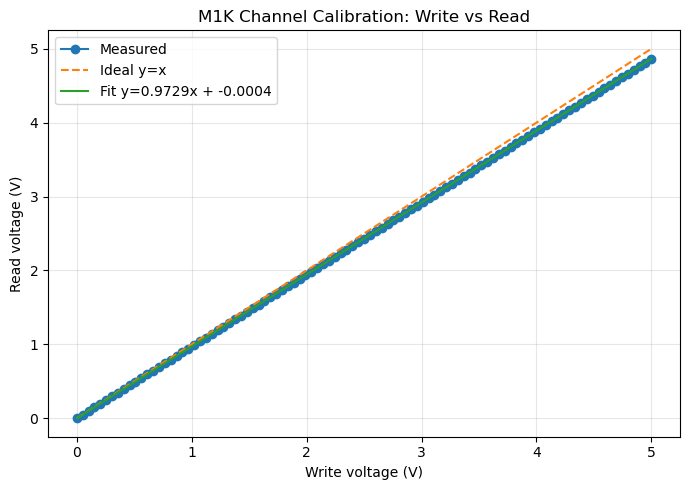

In [16]:
plt.figure(figsize=(7, 5))
plt.plot(write_v, read_v, "o-", label="Measured")
plt.plot(write_v, write_v, "--", label="Ideal y=x")
plt.plot(write_v, fit_v, label=f"Fit y={gain:.4f}x + {offset:.4f}")
plt.xlabel("Write voltage (V)")
plt.ylabel("Read voltage (V)")
plt.title("M1K Channel Calibration: Write vs Read")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()